<a href="https://colab.research.google.com/github/AyushBanode/Projects/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
import numpy as np

In [10]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
data = pd.read_csv('/content/zomato.csv', skiprows=[434,891,766,920,1036,1173,1410], on_bad_lines='skip', engine='python')
data.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [12]:
data.shape

(33112, 17)

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
data.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33112 entries, 0 to 33111
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          33112 non-null  object
 1   address                      33112 non-null  object
 2   name                         33112 non-null  object
 3   online_order                 33112 non-null  object
 4   book_table                   33112 non-null  object
 5   rate                         28161 non-null  object
 6   votes                        33112 non-null  int64 
 7   phone                        32420 non-null  object
 8   location                     33100 non-null  object
 9   rest_type                    32964 non-null  object
 10  dish_liked                   14880 non-null  object
 11  cuisines                     33085 non-null  object
 12  approx_cost(for two people)  32950 non-null  object
 13  reviews_list                 33

In [16]:
data = data.drop(['url','address','phone','menu_item','listed_in(type)','listed_in(city)'],axis=1)

In [17]:
data.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ..."


In [18]:
data.shape

(33112, 11)

In [19]:
data.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,4951
votes,0
location,12
rest_type,148
dish_liked,18232
cuisines,27
approx_cost(for two people),162


In [20]:
feature_na = [i for i in data.columns if data[i].isnull().sum()>0]
feature_na

['rate',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'approx_cost(for two people)']

In [21]:
for i in feature_na:
  print(f"{i} has {np.round((data[i].isnull().sum()/len(data[i])*100),4)}%null values")

rate has 14.9523%null values
location has 0.0362%null values
rest_type has 0.447%null values
dish_liked has 55.0616%null values
cuisines has 0.0815%null values
approx_cost(for two people) has 0.4892%null values


In [22]:
data.rate.unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '2.4 /5', '4.7 /5'],
      dtype=object)

In [23]:
data.dropna(subset=['rate'],axis=0,inplace=True)

In [24]:
def split(x):
  return x.split('/')[0].strip() #strip will remove the spaces

In [25]:
data.rate = data.rate.apply(split)

In [26]:
data.rate

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
33106,4.4
33108,3.5
33109,4.5
33110,4.3


In [27]:
data.rate.unique()

array(['4.1', '3.8', '3.7', '3.6', '4.6', '4.0', '4.2', '3.9', '3.1',
       '3.0', '3.2', '3.3', '2.8', '4.4', '4.3', 'NEW', '2.9', '3.5',
       '2.6', '3.4', '4.5', '2.5', '2.7', '4.7', '2.4', '2.2', '2.3', '-',
       '4.8', '4.9', '2.1', '2.0', '1.8'], dtype=object)

In [28]:
data['rate'].replace(['NEW','-'],0,inplace=True)

In [29]:
data['rate'] = data['rate'].astype(float)

In [30]:
data['rate']

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
33106,4.4
33108,3.5
33109,4.5
33110,4.3


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28161 entries, 0 to 33111
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         28161 non-null  object 
 1   online_order                 28161 non-null  object 
 2   book_table                   28161 non-null  object 
 3   rate                         28161 non-null  float64
 4   votes                        28161 non-null  int64  
 5   location                     28161 non-null  object 
 6   rest_type                    28055 non-null  object 
 7   dish_liked                   14850 non-null  object 
 8   cuisines                     28156 non-null  object 
 9   approx_cost(for two people)  28046 non-null  object 
 10  reviews_list                 28161 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 2.6+ MB


In [32]:
data['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '1,700', '1,400', '1,350', nan, '2,200',
       '2,000', '1,800', '1,900', '180', '330', '2,500', '2,100', '3,000',
       '2,800', '3,400', '50', '40', '1,250', '3,500', '4,000', '2,400',
       '2,600', '1,450', '70', '3,200', '560', '240', '360', '6,000',
       '1,050', '2,300'], dtype=object)

In [33]:
def ac(x):
  return x.replace(',','')

In [34]:
data['approx_cost(for two people)'] = data['approx_cost(for two people)'].astype(str).apply(ac)

In [35]:
data['approx_cost(for two people)'].astype(float)

,approx_cost(for two people)
0,800.0
1,800.0
2,800.0
3,300.0
4,600.0
...,...
33106,800.0
33108,400.0
33109,1400.0
33110,800.0


In [36]:
#calculating avg rating for each
rating = pd.pivot_table(data,index='name',values='rate')
rating

,rate
name,
#FeelTheROLL,3.400000
#L-81 Cafe,3.900000
#refuel,3.700000
1000 B.C,3.200000
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,3.700000
...,...
i-Bar - The Park Bangalore,3.800000
iFruit Live Ice Creams,3.400000
iSpice Resto Cafe,3.700000


In [37]:
rating = rating.sort_values(by='rate',ascending=False)
rating[0:15]

,rate
name,
Punjab Grill,4.900000
Byg Brewski Brewing Company,4.900000
Flechazo,4.900000
Asia Kitchen By Mainland China,4.900000
Belgian Waffle Factory,4.838889
The Pizza Bakery,4.800000
AB's - Absolute Barbecues,4.800000
Brahmin's Coffee Bar,4.800000
House Of Commons,4.733333


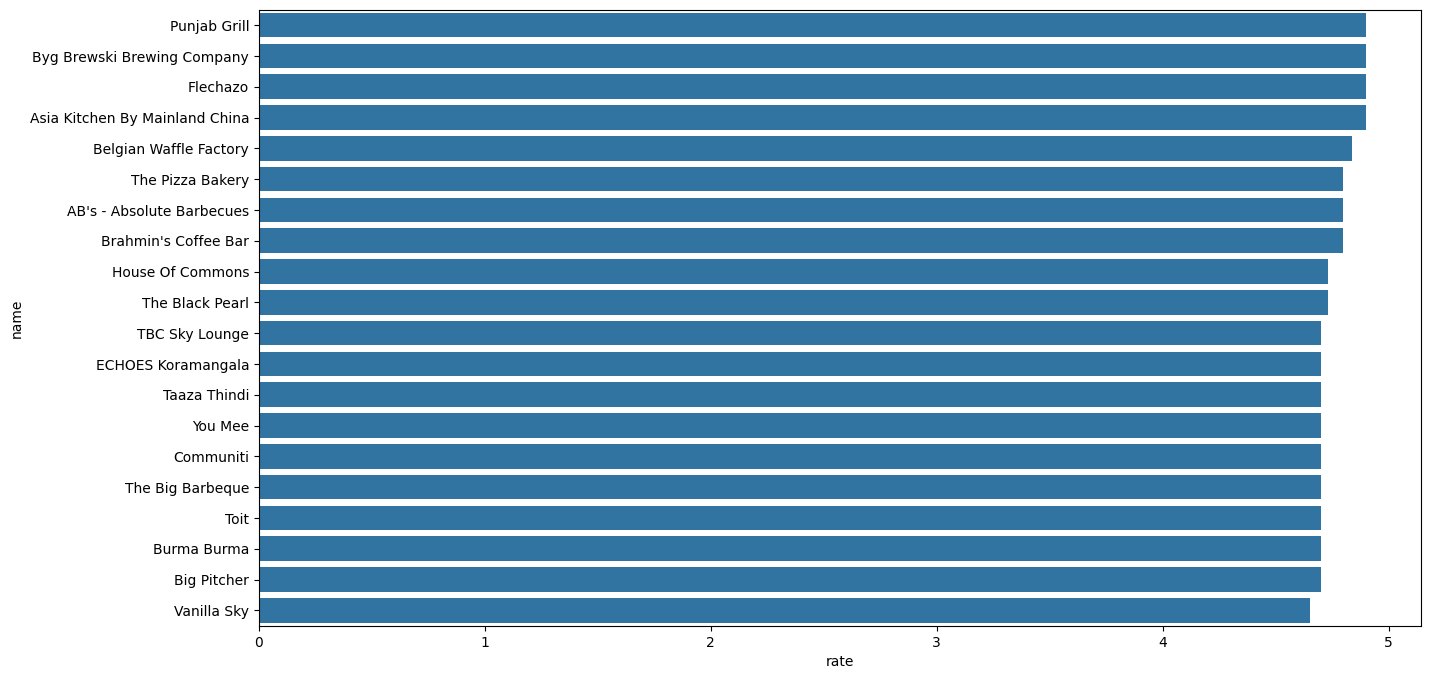

In [38]:
plt.figure(figsize=(15,8))
sns.barplot(x=rating[0:20].rate,y=rating[0:20].index,orient="h")
plt.show()

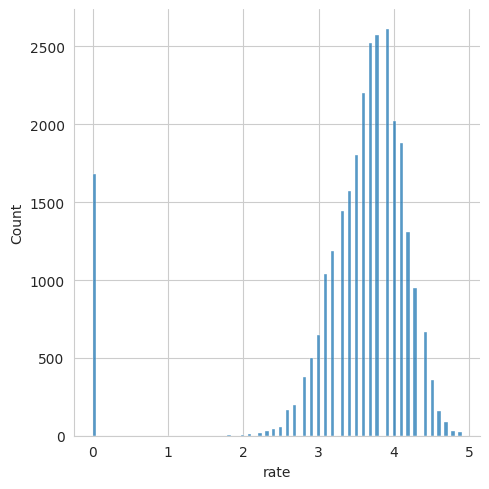

In [39]:
sns.set_style('whitegrid')
sns.displot(data['rate'])

plt.show()

In [40]:
from scipy.stats import normaltest
DataToTest = data['rate']
stat, p = normaltest(DataToTest)
print('Statistics=%.3f, p=%.3f' % (stat, p))

if p>0.05:
  print('Normal Distribution')
else:
  print('Not a Normal Distribution')

Statistics=15094.968, p=0.000
Not a Normal Distribution


In [41]:
def find_outlier_IQR(data):
  out=[]
  q1 = data.quantile(0.25)
  q3 = data.quantile(0.75)
  IQR = q3-q1
  upper=q3+1.5*IQR
  lower=q1-1.5*IQR
  for i in data:
    if i>upper or i<lower:
      out.append(i)
  return out